In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure

## Task 1

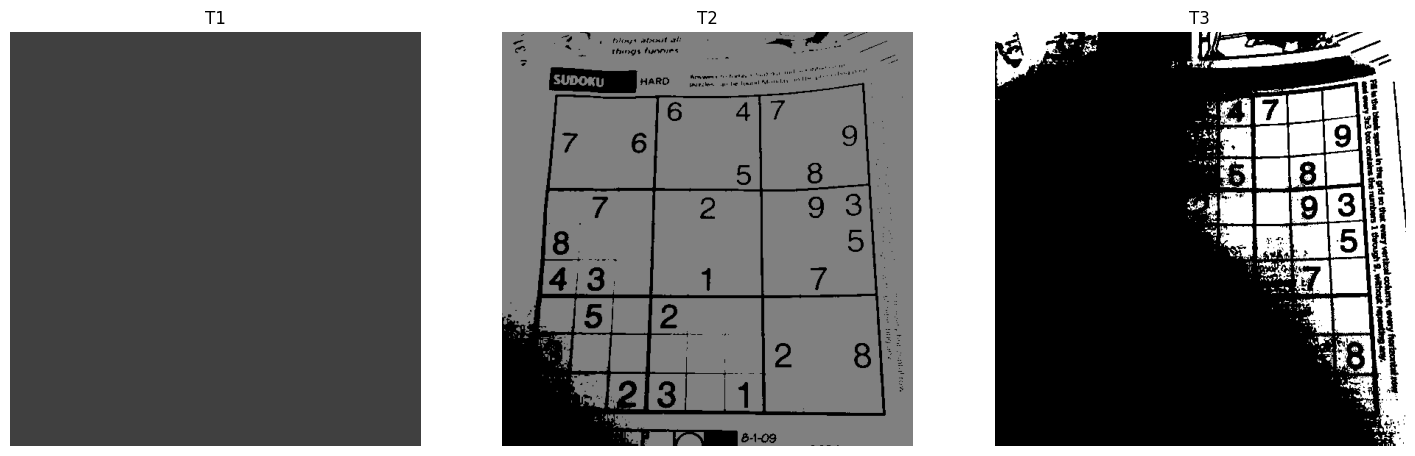

In [7]:
sudoku = cv2.imread("sudoku.png", cv2.IMREAD_GRAYSCALE)

_, sudoku_t1 = cv2.threshold(sudoku, 0, 64, cv2.THRESH_BINARY)
_, sudoku_t2 = cv2.threshold(sudoku, 64, 128, cv2.THRESH_BINARY)
_, sudoku_t3 = cv2.threshold(sudoku, 128, 255, cv2.THRESH_BINARY)

sudoku_t1_rgb = cv2.cvtColor(sudoku_t1, cv2.COLOR_BGR2RGB)
sudoku_t2_rgb = cv2.cvtColor(sudoku_t2, cv2.COLOR_BGR2RGB)
sudoku_t3_rgb = cv2.cvtColor(sudoku_t3, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(sudoku_t1_rgb)
axes[0].set_title("T1")
axes[0].axis("off")

axes[1].imshow(sudoku_t2_rgb)
axes[1].set_title("T2")
axes[1].axis("off")

axes[2].imshow(sudoku_t3_rgb)
axes[2].set_title("T3")
axes[2].axis("off")

plt.show()

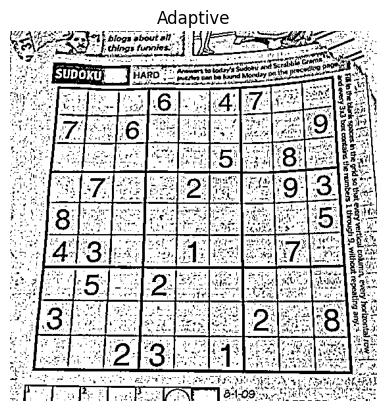

In [8]:
sudoku_adap = cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

sudoku_adap_rgb = cv2.cvtColor(sudoku_adap, cv2.COLOR_BGR2RGB)

plt.imshow(sudoku_adap_rgb)
plt.title("Adaptive")
plt.axis("off")
plt.show()

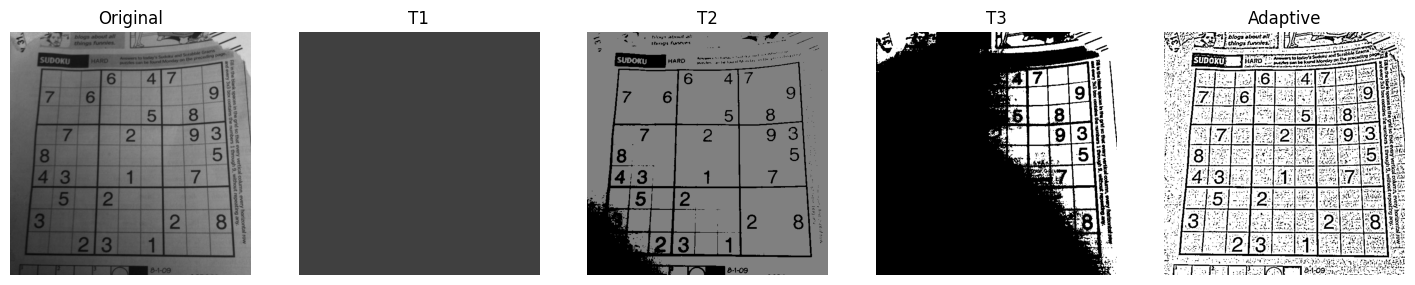

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(sudoku, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(sudoku_t1_rgb)
axes[1].set_title("T1")
axes[1].axis("off")

axes[2].imshow(sudoku_t2_rgb)
axes[2].set_title("T2")
axes[2].axis("off")

axes[3].imshow(sudoku_t3_rgb)
axes[3].set_title("T3")
axes[3].axis("off")

axes[4].imshow(sudoku_adap_rgb)
axes[4].set_title("Adaptive")
axes[4].axis("off")

plt.show()

The worst is T3. The left side of the image causes global thresholding to fail because its much darker than the right side. Adaptive threshold performs well because it uses different threshold values for different regions of the image

## Task 2 (Adaptive Gaussian, Mean Thresholding)

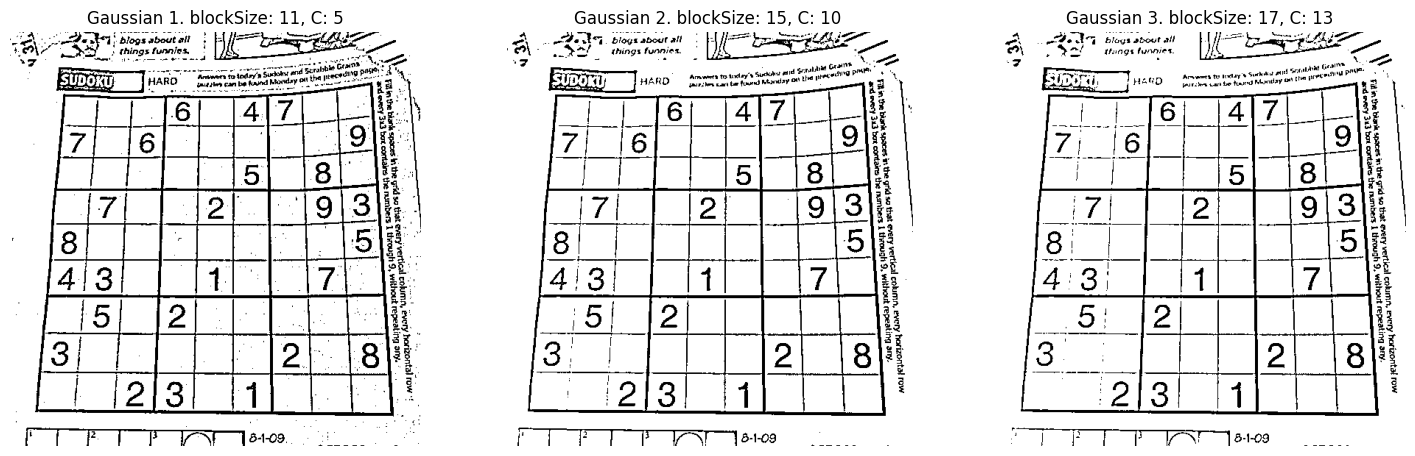

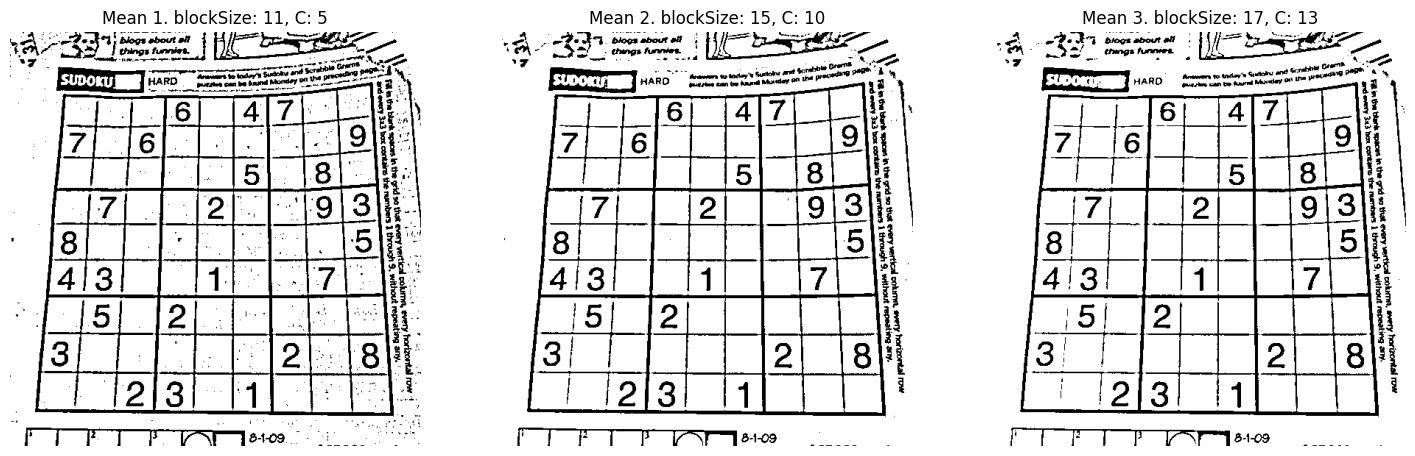

In [12]:
sudoku_adap_1 = cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 5)
sudoku_adap_2 = cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 10)
sudoku_adap_3 = cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 17, 13)

sudoku_adap_4 = cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 5)
sudoku_adap_5 = cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, 10)
sudoku_adap_6 = cv2.adaptiveThreshold(sudoku, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 17, 13)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(sudoku_adap_1, cv2.COLOR_BGR2RGB))
axes[0].set_title("Gaussian 1. blockSize: 11, C: 5")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(sudoku_adap_2, cv2.COLOR_BGR2RGB))
axes[1].set_title("Gaussian 2. blockSize: 15, C: 10")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(sudoku_adap_3, cv2.COLOR_BGR2RGB))
axes[2].set_title("Gaussian 3. blockSize: 17, C: 13")
axes[2].axis("off")

fig_1, axes_1 = plt.subplots(1, 3, figsize=(18, 6))

axes_1[0].imshow(cv2.cvtColor(sudoku_adap_4, cv2.COLOR_BGR2RGB))
axes_1[0].set_title("Mean 1. blockSize: 11, C: 5")
axes_1[0].axis("off")

axes_1[1].imshow(cv2.cvtColor(sudoku_adap_5, cv2.COLOR_BGR2RGB))
axes_1[1].set_title("Mean 2. blockSize: 15, C: 10")
axes_1[1].axis("off")

axes_1[2].imshow(cv2.cvtColor(sudoku_adap_6, cv2.COLOR_BGR2RGB))
axes_1[2].set_title("Mean 3. blockSize: 17, C: 13")
axes_1[2].axis("off")

plt.show()

What happens when the neighbourhood is too small?<br>
Ans: It picks up micro-variations and high-frequency background noise, resulting in the heavy black speckling and artifacts visible along the outer margins and headers in the blockSize: 11 images.

What happens when the neighbourhood is too large?<br>
Ans: The calculation begins to average pixels over too wide an area, causing it to behave like a standard global threshold. So in case of non-uniform lighting it does not do well.

What happens when C is increased?<br>
Ans: Increasing C raises the strictness threshold, which wipes away background noise and speckles, making the white spaces look crisp and clean (as seen when moving from C: 5 to C: 13). However if C is increased too much, actual foreground details begin to erode. The lines of the Sudoku grid and the numbers become noticeably thinner, fainter, or broken (visible in the C: 13 variants where some text strokes start to fade).

Which combination produces the cleanest text segmentation?<br>
Ans: The second combination (blockSize: 15, C: 10) produces the cleanest segmentation.

Which adaptive method performs better on this image?<br>
Ans: Gaussian Adaptive method

## Task 3 (OTSU Thresholding)

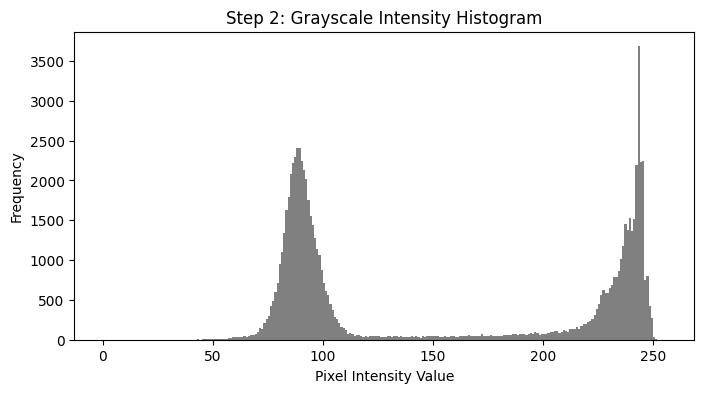

In [22]:
water_coins = cv2.imread("water_coins.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8, 4))
# .ravel() flattens the 2D image array into a 1D array of pixels for the histogram
plt.hist(water_coins.ravel(), bins=256, range=(0, 256), color="gray")
plt.title("Step 2: Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity Value")
plt.ylabel("Frequency")
plt.show()

In [24]:
thresh_orig, mask_orig = cv2.threshold(
    water_coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f"-> Step 4 Record: Automatically Selected Original Threshold = {thresh_orig}")

processed_coins = cv2.convertScaleAbs(water_coins, alpha=1.3, beta=0)
thresh_proc, mask_proc = cv2.threshold(
    processed_coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print(f"-> Step 5 Record: Automatically Selected Preprocessed Threshold = {thresh_proc}")

-> Step 4 Record: Automatically Selected Original Threshold = 162.0
-> Step 5 Record: Automatically Selected Preprocessed Threshold = 183.0


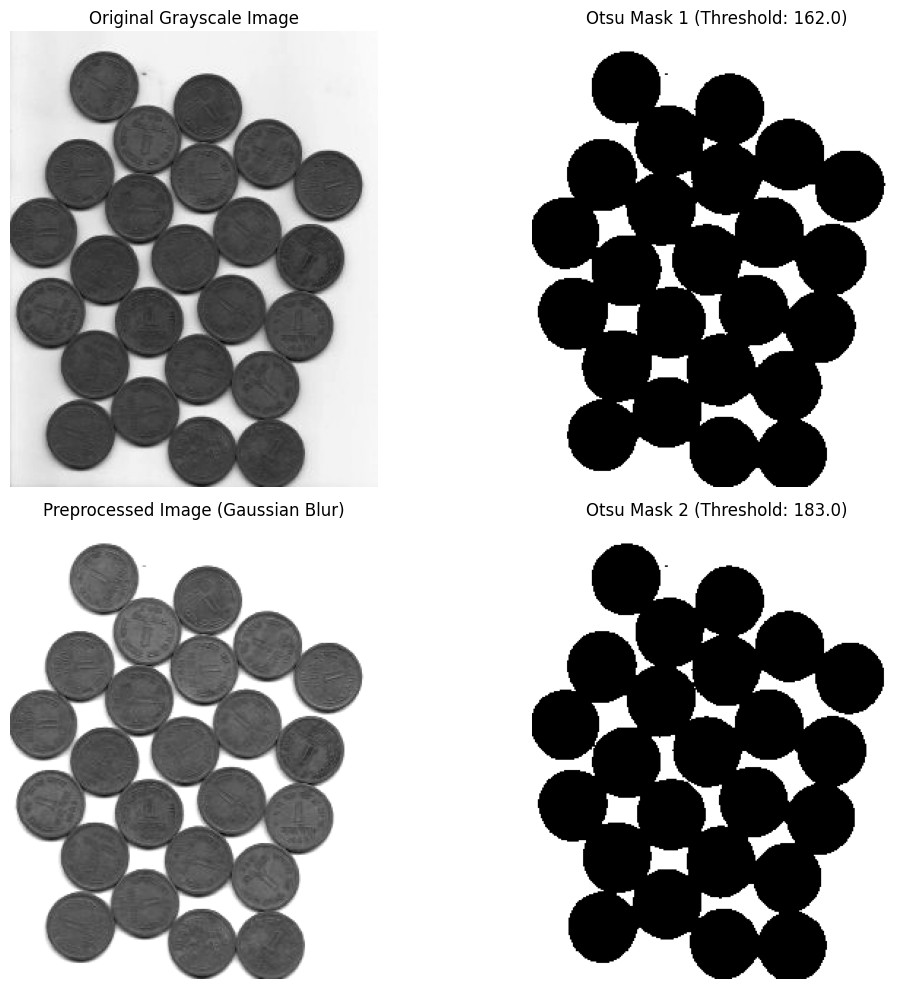

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Row 1: Original Pipeline
axes[0, 0].imshow(water_coins, cmap="gray")
axes[0, 0].set_title("Original Grayscale Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(mask_orig, cmap="gray")
axes[0, 1].set_title(f"Otsu Mask 1 (Threshold: {thresh_orig})")
axes[0, 1].axis("off")

# Row 2: Preprocessed Pipeline
axes[1, 0].imshow(processed_coins, cmap="gray")
axes[1, 0].set_title("Preprocessed Image (Gaussian Blur)")
axes[1, 0].axis("off")

axes[1, 1].imshow(mask_proc, cmap="gray")
axes[1, 1].set_title(f"Otsu Mask 2 (Threshold: {thresh_proc})")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Task 4 (Color-Based Segmentation)

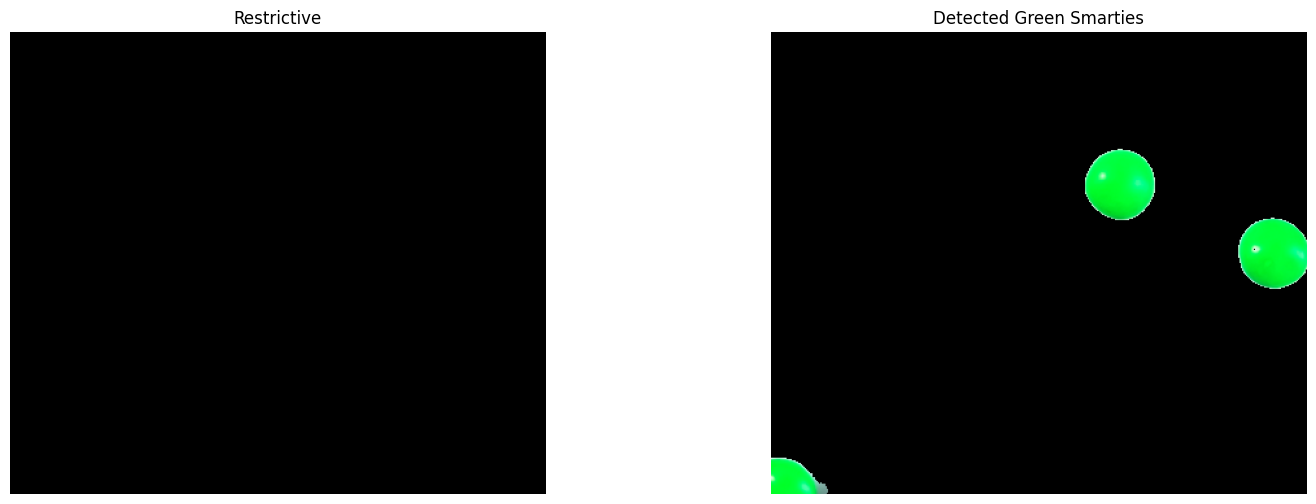

In [35]:
smarties = cv2.imread("smarties.png")

smarties_hsv = cv2.cvtColor(smarties, cv2.COLOR_BGR2HSV)
lower_bound_restrictive = np.array([30, 50, 50])
upper_bound_restrictive = np.array([60, 255, 255])

mask_restrictive = cv2.inRange(smarties_hsv, lower_bound_restrictive, upper_bound_restrictive)
result_restrictive = cv2.bitwise_and(smarties, smarties, mask=mask_restrictive)

lower_bound = np.array([35, 40, 40])   
upper_bound = np.array([85, 255, 255])  

mask = cv2.inRange(smarties_hsv, lower_bound, upper_bound)

result = cv2.bitwise_and(smarties, smarties, mask=mask)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(result_restrictive, cv2.COLOR_BGR2RGB))
axes[0].set_title("Restrictive")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1].set_title("Detected Green Smarties")
axes[1].axis("off")

plt.show()

Restrictive mask fails because it does not define the hue correctly thus green cannot be detected.

## Task 5 (Canny Edge)

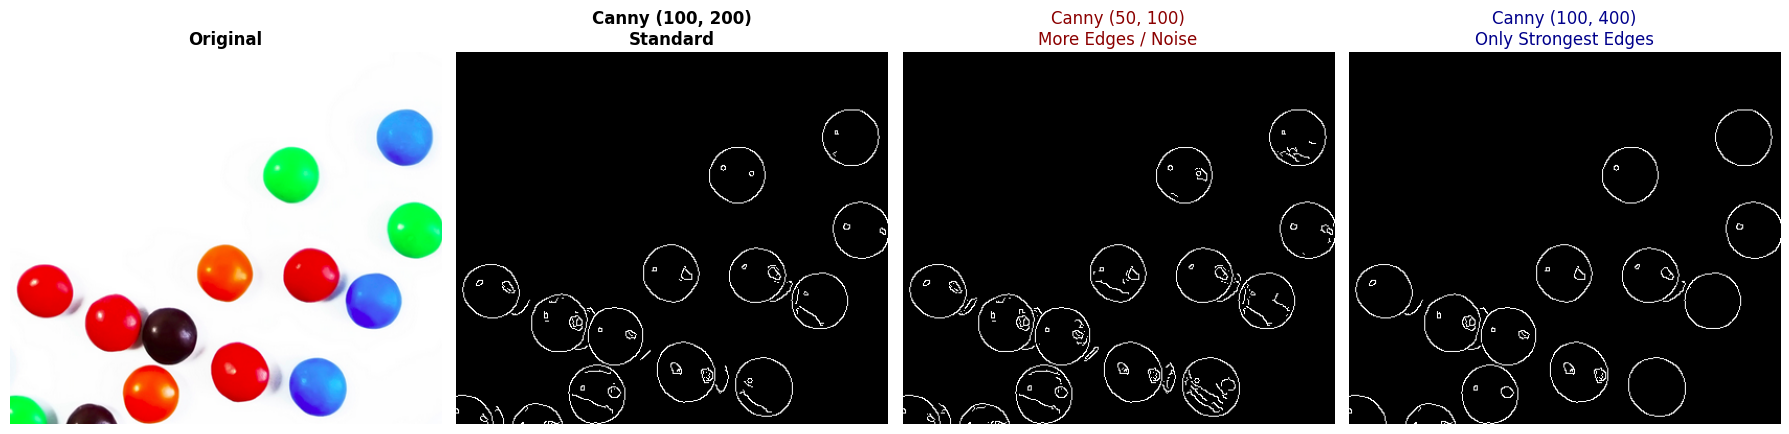

In [39]:
edges_1 = cv2.Canny(smarties, 100, 200)
edges_2 = cv2.Canny(smarties, 50, 100)
edges_3 = cv2.Canny(smarties, 100, 400)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(smarties, cv2.COLOR_BGR2RGB), cmap="gray")
axes[0].set_title("Original", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(edges_1, cmap="gray")
axes[1].set_title("Canny (100, 200)\nStandard", fontsize=12, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(edges_2, cmap="gray")
axes[2].set_title(
    "Canny (50, 100)\nMore Edges / Noise", fontsize=12, color="darkred"
)
axes[2].axis("off")

axes[3].imshow(edges_3, cmap="gray")
axes[3].set_title(
    "Canny (100, 400)\nOnly Strongest Edges", fontsize=12, color="darkblue"
)
axes[3].axis("off")

plt.tight_layout()
plt.show()

The upperbound threshold makes sure only the strongest edges are detected, meaning the weak edges of light present on the skittles are detected less

## Task 6 (Region Growing)

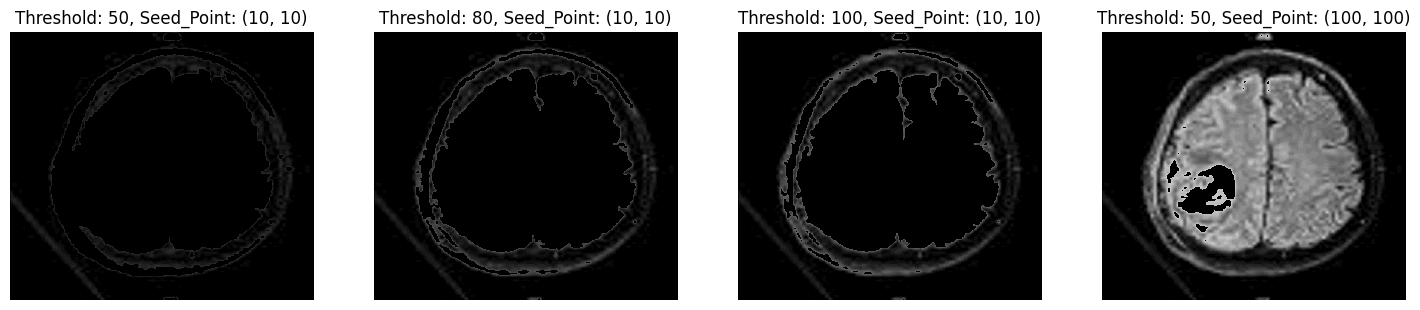

In [47]:
brain_mri = cv2.imread("brain_mri.png", cv2.IMREAD_GRAYSCALE)

seed_point_1 = (10, 10)
seed_point_2 = (100, 100)

def region_growing(image, seed, threshold):
    h, w = image.shape
    mask = np.zeros((h, w), dtype=np.uint8)
    stack = [seed]
    seed_intensity = image[seed]

    while stack:
        x, y = stack.pop()

        if x < 0 or x >= image.shape[0] or y < 0 or y >= image.shape[1]:
            continue

        if mask[x, y] == 0:
            if abs(int(image[x, y])) - int(seed_intensity) < threshold:
                mask[x, y] = 255
                stack.extend([(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)])
    return mask

threshold_1, threshold_2, threshold_3 = 50, 80, 100
segmented_image_mask_1 = region_growing(brain_mri, seed_point_1, threshold_1)
segmented_image_mask_2 = region_growing(brain_mri, seed_point_1, threshold_2)
segmented_image_mask_3 = region_growing(brain_mri, seed_point_1, threshold_3)

segmented_image_mask_4 = region_growing(brain_mri, seed_point_2, threshold_1)

result_1 = cv2.bitwise_and(brain_mri, brain_mri, mask=segmented_image_mask_1)
result_2 = cv2.bitwise_and(brain_mri, brain_mri, mask=segmented_image_mask_2)
result_3 = cv2.bitwise_and(brain_mri, brain_mri, mask=segmented_image_mask_3)
result_4 = cv2.bitwise_and(brain_mri, brain_mri, mask=segmented_image_mask_4)

fig, axes = plt.subplots(1, 4, figsize=(18, 10))

axes[0].imshow(cv2.cvtColor(result_1, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Threshold: {threshold_1}, Seed_Point: {seed_point_1}")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(result_2, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Threshold: {threshold_2}, Seed_Point: {seed_point_1}")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(result_3, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Threshold: {threshold_3}, Seed_Point: {seed_point_1}")
axes[2].axis("off")

axes[3].imshow(cv2.cvtColor(result_4, cv2.COLOR_BGR2RGB))
axes[3].set_title(f"Threshold: {threshold_1}, Seed_Point: {seed_point_2}")
axes[3].axis("off")

plt.show()

## Task 7 (Marked Based Watershed Segmentation)

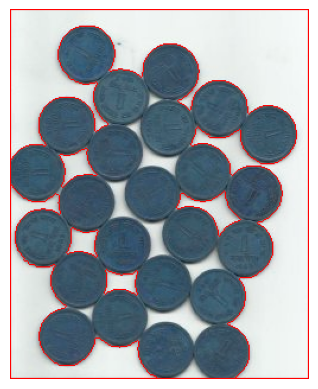

In [49]:
water_coins = cv2.imread("water_coins.jpg")

gray = cv2.cvtColor(water_coins, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

cv2.watershed(water_coins, markers)
water_coins[markers == -1] = [255, 0, 0]

plt.imshow(water_coins)
plt.axis("off")
plt.show()

## Task 8 (Watershed with Distance Transform)

Exp  Multiplier     Foreground Markers  Separated Regions   
-----------------------------------------------------------------
1    0.1            1                   1                   
2    0.4            27                  27                  
3    0.7            24                  24                  
4    0.9            24                  24                  


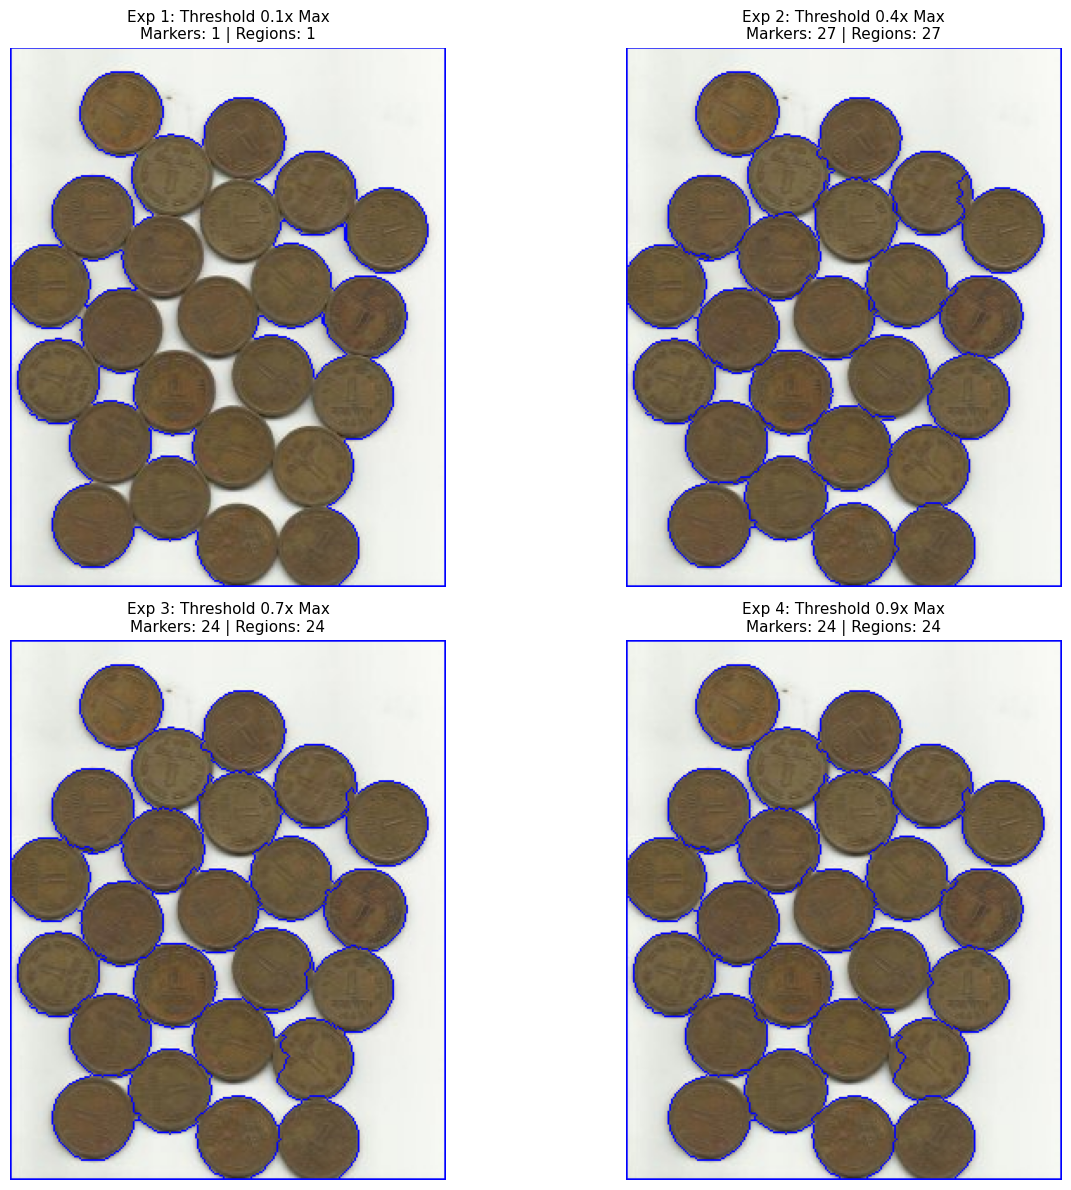

In [50]:
# Morphological Preprocessing steps from Task 7
_, thresh = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Compute raw Distance Transform matrix
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Define 4 distinct threshold multipliers to evaluate
threshold_multipliers = [0.1, 0.4, 0.7, 0.9]

# Setup a clean grid plot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

print(
    f"{'Exp':<5}{'Multiplier':<15}{'Foreground Markers':<20}{'Separated Regions':<20}"
)
print("-" * 65)

for idx, mult in enumerate(threshold_multipliers):
    # Create copy of base image to overlay watershed lines safely
    img_copy = water_coins.copy()

    # Apply variable distance transform thresholding
    _, sure_fg = cv2.threshold(
        dist_transform, mult * dist_transform.max(), 255, 0
    )
    sure_fg = np.uint8(sure_fg)

    # Calculate markers using Connected Components
    # num_labels includes the background label (0)
    num_labels, markers = cv2.connectedComponents(sure_fg)

    # Isolate unknown boundary zone
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Adjust marker indexes to separate labels from watershed boundaries
    markers = markers + 1
    markers[unknown == 255] = 0

    # Execute Watershed Segmentation
    cv2.watershed(img_copy, markers)
    img_copy[markers == -1] = [255, 0, 0]  # Draw Red boundaries

    # Compute descriptive tracking statistics
    # Foreground markers count = total component labels minus background
    fg_markers_count = num_labels - 1

    # Total distinct segmented foreground regions tracked on final canvas
    # (Excludes background label '1' and boundary label '-1')
    unique_regions = len(np.unique(markers)) - 2
    # Safe boundary check in case labels disappear completely
    separated_regions = max(0, unique_regions)

    print(f"{idx+1:<5}{mult:<15}{fg_markers_count:<20}{separated_regions:<20}")

    # Plot visual outcome matrices
    axes[idx].imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(
        f"Exp {idx+1}: Threshold {mult}x Max\nMarkers: {fg_markers_count} | Regions: {separated_regions}",
        fontsize=11,
    )
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


## Task 9 (KMEANS)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [60.0157..180.49904].


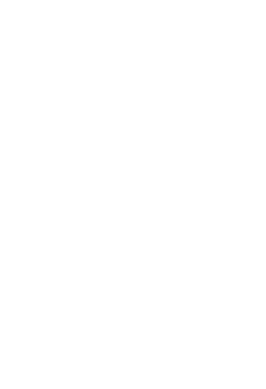

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [53.970783..200.75006].


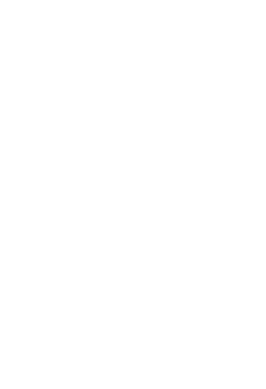

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [53.16345..208.7603].


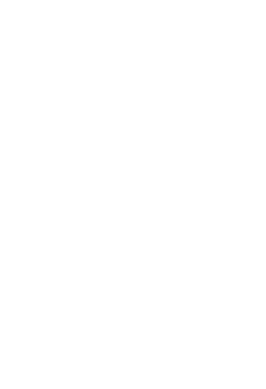

In [55]:
dog = cv2.imread("dog.jpeg")

pixel_values = dog.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

for K in [2, 4, 6]:
    _, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    cneters = np.uint8(centers)
    segmented_image = centers[labels.flatten()]

    segmented_image = segmented_image.reshape(dog.shape)

    plt.imshow(segmented_image)
    plt.axis("off")
    plt.show()

## Task 10

**Chosen image:** `smarties.png` - colored candies on a white background, with soft shadows, specular highlights, a very dark (brown) candy, and candies that nearly touch (red/brown). 
**Methods:** Otsu's thresholding, Color-based (HSV) thresholding, K-Means (CIE-Lab).

In [57]:
img = cv2.imread("smarties.png")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

def n_regions(mask, min_area=100):
    n, _, stats, _ = cv2.connectedComponentsWithStats(mask)
    return int((stats[1:, cv2.CC_STAT_AREA] >= min_area).sum())

# Method 1: Otsu on grayscale (candies darker than background -> invert)
t_otsu, m1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Method 2: colour-based - candies are saturated, white background and grey shadow are not
m2 = cv2.inRange(hsv, (0, 60, 40), (180, 255, 255))
m2 = cv2.morphologyEx(m2, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

# Method 3: K-Means (K=2) on Lab colour -> pick the cluster that is NOT the background
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).reshape(-1, 3).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(lab, 2, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
bg = np.argmax(centers[:, 0])  # brightest cluster = background
m3 = ((labels.ravel() != bg).astype(np.uint8) * 255).reshape(gray.shape)

for name, m in [("Otsu", m1), ("HSV colour", m2), ("K-Means", m3)]:
    print(f"{name:10s} foreground = {100 * (m > 0).mean():5.1f}%  regions = {n_regions(m)}")
print("Otsu threshold =", t_otsu)

Otsu       foreground =  19.7%  regions = 13
HSV colour foreground =  19.6%  regions = 13
K-Means    foreground =  15.9%  regions = 10
Otsu threshold = 176.0


### Method analysis

| | Otsu (grayscale) | HSV colour threshold | K-Means (Lab, K=2) |
|---|---|---|---|
| **1. Assumption** | The histogram is bimodal: dark objects vs. one bright background, separable by a single global grey level. | Objects differ from the background in *chroma* (saturation), not brightness; background is unsaturated white/grey. | Pixels fall into K compact clusters in colour space; K=2 means "background colour" vs. "everything else". |
| **2. Identified correctly** | Bright-saturated candies (red, orange, green, blue) and the dark brown candy, whose grey level is far below the background. | All candies including the dark brown one, with the shadows excluded because they are grey (low saturation). | The main candy bodies, separated from the white background without any manual threshold. |
| **3. Incorrectly segmented** | Soft shadows around the candies are darker than the cut-off and get absorbed into the mask; touching candies (red + brown) merge into one blob; bright-yellowish/light regions of a candy may be lost. | Specular highlights (low S) punch holes in candies; dark brown candy has low V/S so it is fragile near the boundary; touching candies still merge. | The shadow pixels are closer in Lab to the background than to a candy so they mostly fall in the background, but the faint edge/shadow gradient and the dark brown candy can be assigned unpredictably; touching candies still merge. |
| **4. Most influential parameter** | The (automatic) threshold value itself - its position relative to the shadow grey level decides whether shadows are included. | The saturation lower bound (S_min): too low includes shadows, too high drops pale/dark candies. | K (number of clusters) and the colour space; K=2 forces a binary split while K>2 splits one candy into highlight/body/edge. |

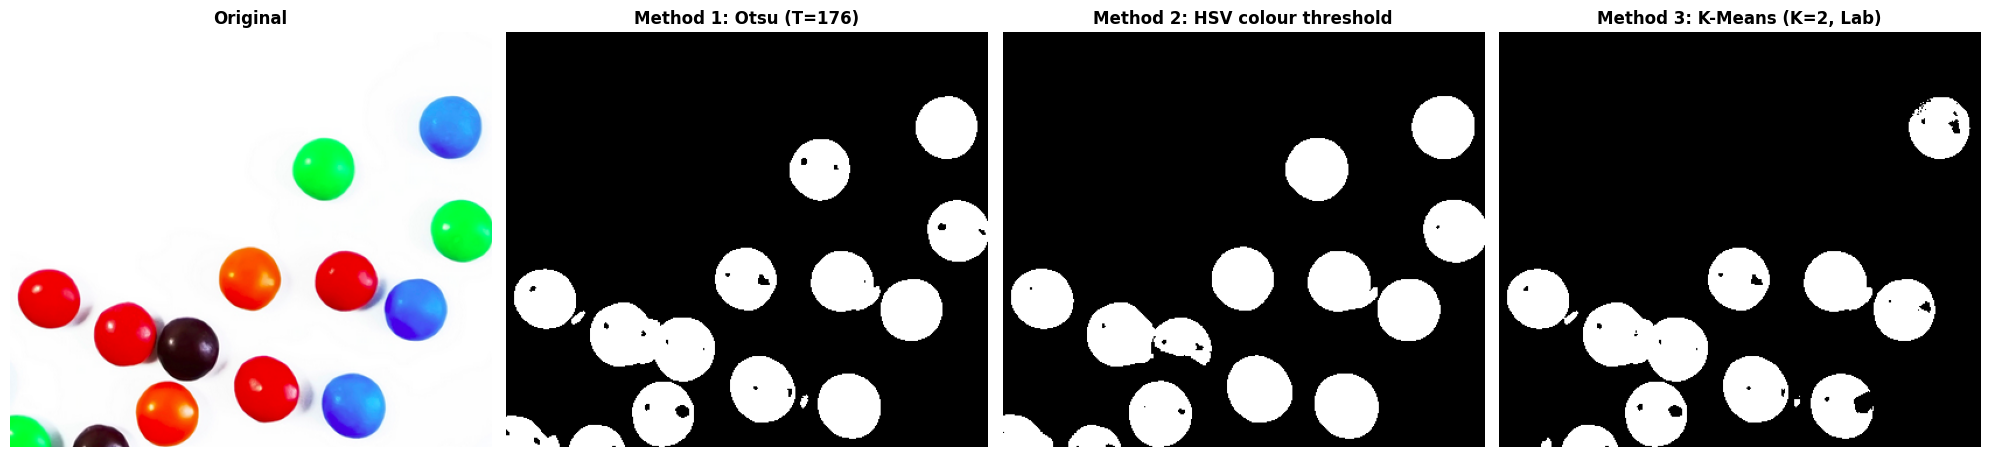

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, im, t, c in [(axes[0], rgb, "Original", None),
                     (axes[1], m1, f"Method 1: Otsu (T={t_otsu:.0f})", "gray"),
                     (axes[2], m2, "Method 2: HSV colour threshold", "gray"),
                     (axes[3], m3, "Method 3: K-Means (K=2, Lab)", "gray")]:
    ax.imshow(im, cmap=c)
    ax.set_title(t, fontsize=12, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()